# Record repair and openness evidence pool (iteration 5, evaluation 4)

This notebook is a runnable walk-through of the artifact's **`eval.py`** and the scripts it drives
(`src/synthesis.py`, `vendor/ladder.py`, `vendor/rq1stats.py`, `src/figures.py`). The original code is copied
with as few changes as possible.

**What the artifact does.** It uses no new data and spends $0 on LLMs. It does three jobs:
1. **Record repair.** It clears the 10 MUST-FIX reviewer items as correction blocks, applies them to a copy of
   the research report, and re-verifies every number against its source file (ledger v3 = 1,290 rows, ledger v4 = 1,769 rows).
2. **Gates G0-G3.** It re-reproduces earlier results exactly: Exp10's EXP5 and cohort `OPEN_home` partial
   Spearman values, and Eval3's ledger.
3. **Evidence synthesis.** It pools the home-only openness indices `OPEN_home` and `NOVCHURN_home` across every body
   scored so far. The effect size is the rank-residual **partial Spearman (psp)** of the index with the uptake
   outcome `O2r_m50`. It is computed at covariate rungs R0/R2/R3 with a concept bootstrap that refits the
   residualisation in every draw. Pooling is **DerSimonian-Laird on Fisher z with an HKSJ interval**, over the
   *non-selection* bodies only.

**What runs live here.** The original inputs are 12k-concept parquet tables that cannot be shipped with a demo.
`mini_demo_data.json` therefore holds:
* `examples`: the **held-out MATHDEC body** (86 concepts, the smallest body). The notebook recomputes
  `OPEN_home` / `NOVCHURN_home` from the raw HOME network components with the frozen EXP5 constants, and re-runs the
  psp bootstrap and the permutation placebo for all 6 MATHDEC cells *live*.
* `context`: the artifact's stored results for the other bodies (`evidence_synthesis.json`), plus the ledger,
  corrections and reference summaries that `eval.py` assembles.

The live MATHDEC cells then replace the stored ones, the DL/HKSJ pools are recomputed, `eval.py`'s metric assembly
runs, and the forest plot (`figures.py`) is redrawn.

## Setup
Install the packages. Colab's pre-installed ones (numpy, pandas, scipy, matplotlib) are installed only when not on Colab, at Colab's versions.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scipy, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0')

Imports: the union of the original import blocks of `eval.py`, `src/synthesis.py`, `vendor/ladder.py`, `vendor/rq1stats.py` and `src/figures.py`. Only the `sys.path` / `paths` module lines were dropped, because everything is defined inline below.

In [2]:
import csv
import json
import math
import os
import sys
from concurrent.futures import ProcessPoolExecutor
from pathlib import Path

for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ.setdefault(_v, "1")
sys.dont_write_bytecode = True

import numpy as np
import pandas as pd
from loguru import logger
from scipy import stats
from scipy.stats import rankdata

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

Data loading helper: GitHub URL first, local `mini_demo_data.json` as fallback.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8795ea-concepts-spread-once-adopters-make-them/fork/run_hy6I3YyVxPEP/round-5/evaluation-4/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"examples (held-out MATHDEC concepts): {len(data['examples'])}")
print("context keys:", list(data["context"]))

examples (held-out MATHDEC concepts): 86
context keys: ['frozen_open_constants', 'evidence_synthesis', 'ledger_rerun', 'corrections_applied', 'per_group_table', 'refs_summary', 'artifact_counts', 'not_found_notes', 'inputs_manifest']


## Config
These are the tunable parameters of `src/synthesis.py` (`--nboot`, `--nperm`, `--workers`) and the frozen
seeds. The artifact ran with `--nboot 2000 --nperm 200 --workers 3` (`eval.py` passes these). On the 86-concept
MATHDEC body the full values take only seconds, so the demo uses them. With `NBOOT = 2000` and Exp10's seed, the
live bootstrap CIs reproduce the stored ones exactly.

In [5]:
NBOOT = 2000       # bootstrap draws per psp cell (original: 2000)
NPERM = 200        # outcome permutations for the placebo (original: 200)
WORKERS = 3        # ProcessPoolExecutor workers (original: 3)

SEED_E10 = 20260929          # Exp10 frozen_spec.bootstrap.seed (used for the gates so CIs are comparable)
SEED_PLAN = 0                # plan's seed; reported alongside for G2
FEATS = ["OPEN_home", "NOVCHURN_home"]
RUNGS = ["R0", "R2", "R3"]
HELD = ["PHYS", "LIFEENV", "SOC", "MATHDEC"]

## 1. The estimator: rank-residual partial Spearman (`vendor/rq1stats.py`)
`psp = Pearson(resid(rank x | 1, ranks of continuous covariates, dummies), resid(rank y | same))`.
This is copied verbatim from Exp10's `rq1stats.py`. Only the two functions the synthesis uses are included.

In [6]:
def _resid(Z: np.ndarray, Y: np.ndarray) -> np.ndarray:
    beta, *_ = np.linalg.lstsq(Z, Y, rcond=None)
    return Y - Z @ beta


def psp_point(x: np.ndarray, y: np.ndarray, B: np.ndarray, cat: np.ndarray | None) -> float:
    """Pearson(resid(rank x ~ rank B + cat dummies), resid(rank y ~ same)). Rows must be complete."""
    Zc = [np.ones((len(x), 1))]
    if B is not None and B.shape[1]:
        Zc.append(rankdata(B, axis=0))
    if cat is not None and cat.shape[1]:
        Zc.append(cat)
    Z = np.hstack(Zc)
    R = _resid(Z, np.c_[rankdata(x), rankdata(y)])
    sx, sy = R[:, 0].std(), R[:, 1].std()
    if sx <= 1e-12 or sy <= 1e-12:
        return float("nan")
    return float(np.corrcoef(R[:, 0], R[:, 1])[0, 1])

## 2. Ladder machinery (`vendor/ladder.py`, verbatim excerpt)
* `open_score` builds OPEN from six network components of a concept's early (t0..t0+2) HOME ego network. Each
  component is winsorised with the **frozen** EXP5 bounds, z-scored and signed, then averaged. The score is NaN
  when fewer than 4 of the 6 are finite or the concept has fewer than 10 home papers.
* `rung_design` gives the covariates of each rung. R0 = B5 size/growth controls + t0 dummies. R2 adds contact
  reach, concept type, generic flag and level. R3 adds the footprint covariates.
* `psp_boot2` = point psp + concept bootstrap (ranks and residualisation refitted in every draw).

In [7]:
COMPONENTS = ["new_edge_rate", "n_comm_W3", "participation", "NOV_res", "ego_density_W3", "edge_persistence"]
SIGNS = {"new_edge_rate": 1, "n_comm_W3": 1, "participation": 1, "NOV_res": 1, "ego_density_W3": -1,
         "edge_persistence": -1}
BUILDS = ["home", "all", "sizematch"]
B5 = ["logvol", "growth_c", "offhome_share", "entropy", "reach"]
FOOTPRINT = ["fp_logN", "fp_nfields"]
FOOTPRINT_BIN = ["fp_reemerge", "fp_wiki_pre", "newborn"]
COVERAGE = ["label_coverage_early", "home_coverage_early"]
ANALYSIS_GROUP = {"CS": "CS+Eng", "Eng": "CS+Eng", "BGM": "BGM+Med", "Med": "BGM+Med", "PHYS": "PHYS",
                  "LIFEENV": "LIFEENV", "SOC": "SOC", "MATHDEC": "MATHDEC"}
POOL_GROUPS = ["CS+Eng", "BGM+Med", "PHYS", "LIFEENV", "SOC"]
LADDER_RUNGS = ["R0", "R1", "R2", "R3", "R4", "R5"]   # ladder.py calls this RUNGS; renamed here only because
                                                       # synthesis.py's RUNGS (R0/R2/R3) shares the namespace
MIN_HOME_PAPERS = 10


# ----------------------------------------------------------------------------- OPEN
def open_score(df: pd.DataFrame, build: str, const: dict, min_home: int = MIN_HOME_PAPERS,
               min_comp: int = 4) -> tuple[np.ndarray, pd.DataFrame]:
    """OPEN_b (NaN unless >= min_comp of 6 z-scores finite; HOME/SIZEMATCH NaN if < min_home home papers t0..t0+2)."""
    Z = pd.DataFrame(index=df.index)
    for k in COMPONENTS:
        c = const[k]
        v = df[f"{k}__{build}"].to_numpy(float)
        Z[k] = c["sign"] * (np.clip(v, c["lo"], c["hi"]) - c["mu"]) / c["sd"]
    nfin = np.isfinite(Z.to_numpy()).sum(1)
    with np.errstate(invalid="ignore"):
        o = np.nanmean(np.where(np.isfinite(Z.to_numpy()), Z.to_numpy(), np.nan), axis=1)
    o[nfin < min_comp] = np.nan
    if build in ("home", "sizematch"):
        o[df["n_home_early"].to_numpy() < min_home] = np.nan
    return o, Z


# ----------------------------------------------------------------------------- rungs
def type_dummies(df: pd.DataFrame) -> pd.DataFrame:
    t = df["type"].fillna("unlabelled")
    return pd.DataFrame({f"type_{c}": (t == c).astype(float) for c in ("method", "object", "property", "unlabelled")},
                        index=df.index)


def level_dummies(df: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame({f"level_{l}": (df.level == l).astype(float) for l in (3, 4, 5)}, index=df.index)


def year_dummies(df: pd.DataFrame) -> pd.DataFrame:
    ys = sorted(df.t0.unique())[1:]
    return pd.DataFrame({f"t0_{y}": (df.t0 == y).astype(float) for y in ys}, index=df.index)


def group_dummies(df: pd.DataFrame) -> pd.DataFrame:
    gs = sorted(df.agroup.unique())[1:]
    return pd.DataFrame({f"g_{g}": (df.agroup == g).astype(float) for g in gs}, index=df.index)


def rung_design(df: pd.DataFrame, rung: str, drop_type: bool = False, drop_group: bool = False
                ) -> tuple[pd.DataFrame, pd.DataFrame]:
    """(continuous covariates -> ranked, categorical dummies -> raw) for rung R0..R5."""
    r = LADDER_RUNGS.index(rung)
    cont = list(B5)
    cat = [year_dummies(df)]
    if "window_flag" in df.columns and df.window_flag.nunique() > 1:
        cat.append(df[["window_flag"]].astype(float))
    if r >= 1:
        cont.append("CONTACT_REACH")
    if r >= 2:
        if not drop_type:
            cat.append(type_dummies(df))
        cat.append(df[["generic"]].astype(float))
        cat.append(level_dummies(df))
    if r >= 3:
        cont += FOOTPRINT
        cat.append(df[FOOTPRINT_BIN].astype(float))
    if r >= 4:
        cont += COVERAGE
    if r >= 5 and not drop_group:
        cat.append(group_dummies(df))
    C = pd.concat(cat, axis=1) if cat else pd.DataFrame(index=df.index)
    C = C.loc[:, C.std() > 0] if len(C) > 1 else C
    return df[cont], C


# ----------------------------------------------------------------------------- estimation
def psp_boot2(x: np.ndarray, y: np.ndarray, B: np.ndarray, C: np.ndarray, n_boot: int, seed: int,
              direction: int = 1, idx_boot: np.ndarray | None = None) -> dict:
    ok = np.isfinite(x) & np.isfinite(y) & np.all(np.isfinite(B), 1) & np.all(np.isfinite(C), 1)
    x, y, B, C = x[ok], y[ok], B[ok], C[ok]
    n = len(x)
    if n < 30 or np.unique(x).size < 3:
        return {"n": int(n), "rho": math.nan, "ci": [math.nan, math.nan], "se": math.nan, "p_one": math.nan,
                "p_two": math.nan, "boot": np.array([])}
    est = psp_point(x, y, B, C)
    rng = np.random.default_rng(seed)
    bs = np.empty(n_boot)
    for b in range(n_boot):
        i = rng.integers(0, n, n)
        Ci = C[i]
        keep = Ci.std(0) > 0 if Ci.shape[1] else np.zeros(0, bool)
        bs[b] = psp_point(x[i], y[i], B[i], Ci[:, keep])
    bs = bs[np.isfinite(bs)]
    lo, hi = np.percentile(bs, [2.5, 97.5])
    p_one = float((np.sum(direction * bs <= 0) + 1) / (len(bs) + 1))
    z = np.arctanh(np.clip(bs, -0.999999, 0.999999))
    se_z = float(np.std(z, ddof=1))
    ze = math.atanh(max(min(est, 0.999999), -0.999999))
    return {"n": int(n), "rho": float(est), "ci": [float(lo), float(hi)], "se": float(np.std(bs, ddof=1)),
            "p_one": p_one, "p_two": float(2 * stats.norm.sf(abs(ze / se_z))) if se_z > 0 else math.nan,
            "boot": bs}

## 3. Data: indices from frozen constants (`src/synthesis.py`)
`add_indices` is verbatim. `frozen_const` and the table builder are the only changed functions. The originals read
Exp10's `results/frozen_spec.json` and join five parquet/CSV files (`exp5_table`). Here the same joined columns come
from `data["examples"]`, which holds the MATHDEC rows of that join, and the constants come from `data["context"]`.

In [8]:
def frozen_const() -> dict:
    # original: json.loads((E10 / "results/frozen_spec.json").read_text())["open_constants"]
    return data["context"]["frozen_open_constants"]


def add_indices(df: pd.DataFrame, const: dict) -> pd.DataFrame:
    o, Z = open_score(df, "home", const["home"])
    df = df.copy()
    df["OPEN_home_re"] = o
    nc = Z[["NOV_res", "edge_persistence"]].to_numpy()          # signs already applied (+NOV_res, -edge_persistence)
    v = np.where(np.isfinite(nc).all(1), nc.mean(1), np.nan)
    v[df["n_home_early"].to_numpy() < 10] = np.nan                  # same HOME min-paper rule as OPEN_home
    df["NOVCHURN_home"] = v
    return df


def exp5_table(const: dict) -> pd.DataFrame:
    # original: frame_concepts.csv + ego_open_exp5 + covariates_exp5 + concept_types + EXP8 outcomes joins;
    # the demo rows are that join's output for the held-out MATHDEC body
    df = pd.DataFrame(data["examples"])
    df = add_indices(df, const)
    df["OPEN_home"] = df["OPEN_home_re"]
    return df


const = frozen_const()
e5 = exp5_table(const)
print(f"EXP5 MATHDEC rows {len(e5)}; OPEN_home finite {np.isfinite(e5.OPEN_home).sum()}, "
      f"NOVCHURN_home finite {np.isfinite(e5.NOVCHURN_home).sum()}")
e5[["name", "t0", "n_home_early", "OPEN_home", "NOVCHURN_home", "O2r_m50"]].head()

EXP5 MATHDEC rows 86; OPEN_home finite 86, NOVCHURN_home finite 67


,name,t0,n_home_early,OPEN_home,NOVCHURN_home,O2r_m50
0,Lucas number,2007,22,-0.776179,-0.719327,2.978960
1,Harnack's inequality,2006,42,-0.761732,NaN,1.000000
2,Polynomial ring,2005,43,-0.799799,-2.041570,3.515151
3,Zero divisor,2007,39,-0.242847,-0.189689,2.537629
4,Joint probability distribution,2004,20,-0.392818,-0.188200,10.033067


## 4. Cell estimation, placebo and pooling functions (`src/synthesis.py`, verbatim)
* `_cell` gives psp + bootstrap CI for one (body, index, rung), plus the bootstrap SE on the Fisher-z scale for pooling.
* `_placebo` permutes the outcome within the body `NPERM` times at R2. Its 95th percentile of |psp| is the noise
  floor for that body.
* `dl_hksj` gives the DerSimonian-Laird random-effects pool on Fisher z, the Hartung-Knapp-Sidik-Jonkman interval
  with t_{k-1}, and I2. Everything is back-transformed to r.

In [9]:
def _cell(args):
    key, df, x, y, rung, nboot, seed = args
    Bc, Cc = rung_design(df, rung)
    r = psp_boot2(df[x].to_numpy(float), df[y].to_numpy(float), Bc.to_numpy(float), Cc.to_numpy(float), nboot, seed)
    bs = r.pop("boot")
    z = np.arctanh(np.clip(bs, -0.999999, 0.999999)) if len(bs) else np.array([])
    r["se_z"] = float(np.std(z, ddof=1)) if len(z) > 1 else math.nan
    r.update({"x": x, "y": y, "rung": rung, "n_boot": nboot, "seed": seed})
    return key, r


def _placebo(args):
    key, df, x, y, nperm, seed = args
    Bc, Cc = rung_design(df, "R2")
    xx, yy, B, C = df[x].to_numpy(float), df[y].to_numpy(float), Bc.to_numpy(float), Cc.to_numpy(float)
    ok = np.isfinite(xx) & np.isfinite(yy) & np.all(np.isfinite(B), 1) & np.all(np.isfinite(C), 1)
    xx, yy, B, C = xx[ok], yy[ok], B[ok], C[ok]
    rng = np.random.default_rng(seed)
    v = np.array([psp_point(xx, rng.permutation(yy), B, C) for _ in range(nperm)])
    return key, {"n": int(ok.sum()), "nperm": nperm, "p95_abs_psp": float(np.nanpercentile(np.abs(v), 95)),
                 "mean_psp": float(np.nanmean(v))}


def dl_hksj(rows: list[dict]) -> dict:
    """DL random effects on Fisher z (se_z from the bootstrap) + HKSJ interval; back-transformed to r."""
    z = np.array([math.atanh(r["rho"]) for r in rows])
    se = np.array([r["se_z"] for r in rows])
    k = len(z)
    w = 1 / se**2
    zf = (w * z).sum() / w.sum()
    Q = float((w * (z - zf) ** 2).sum())
    Cc = w.sum() - (w**2).sum() / w.sum()
    tau2 = max(0.0, (Q - (k - 1)) / Cc) if k > 1 else 0.0
    ws = 1 / (se**2 + tau2)
    mu = float((ws * z).sum() / ws.sum())
    se_dl = math.sqrt(1 / ws.sum())
    I2 = max(0.0, (Q - (k - 1)) / Q) if Q > 0 and k > 1 else 0.0
    q = float((ws * (z - mu) ** 2).sum() / (k - 1)) if k > 1 else math.nan
    se_hk = math.sqrt(q / ws.sum()) if k > 1 else math.nan
    t = stats.t.ppf(0.975, k - 1) if k > 1 else math.nan
    th = math.tanh
    return {"k": k, "est": th(mu), "dl_ci": [th(mu - 1.96 * se_dl), th(mu + 1.96 * se_dl)],
            "hksj_ci": [th(mu - t * se_hk), th(mu + t * se_hk)] if k > 1 else [math.nan, math.nan],
            "Q": Q, "I2": float(I2), "tau2_z": float(tau2), "z": mu, "se_z_dl": se_dl, "se_z_hksj": se_hk,
            "I2_note": "imprecise at small k (k <= 6)"}

## 5. Live re-estimation of the held-out MATHDEC body (`synthesis.py` main, "item 11 cells")
This is the original job loop, restricted to the one body that is shipped. It runs 2 indices x 3 rungs bootstrap
cells and 2 placebo jobs. The live values are then compared with the ones the artifact stored in
`results/evidence_synthesis.json`.

In [10]:
bodies = {f"B2_{g}": ("already-unsealed", "already-unsealed", e5[(e5.split == "HELDOUT") & (e5.group == g)])
          for g in ["MATHDEC"]}      # original: for g in HELD (+ B1_DEV, B2_HELDOUT_pooled, B3, B4)
jobs = []
for bk, (_, _, d) in bodies.items():
    for f in FEATS:
        for r in RUNGS:
            jobs.append((f"{bk}|{f}|{r}", d, f, "O2r_m50", r, NBOOT, SEED_E10))
pjobs = [(f"{bk}|{f}", d, f, "O2r_m50", NPERM, SEED_E10 + 7) for bk, (_, _, d) in bodies.items() for f in FEATS]
res, plc = {}, {}
with ProcessPoolExecutor(WORKERS) as ex:
    for k, r in ex.map(_cell, jobs):
        res[k] = r
        logger.info(f"{k}: {r['rho']:+.3f} [{r['ci'][0]:+.3f}, {r['ci'][1]:+.3f}] n={r['n']}")
    for k, r in ex.map(_placebo, pjobs):
        plc[k] = r

# compare with the artifact's stored values
syn_stored = data["context"]["evidence_synthesis"]
stored = {(r["body"], r["feature"]): r for r in syn_stored["rows"]}
cmp_rows = []
for k, r in res.items():
    b, f, rung = k.split("|")
    s = stored[(b, f)][rung]
    cmp_rows.append({"cell": k, "n": r["n"], "psp_live": r["rho"], "psp_stored": s["psp"],
                     "abs_diff": abs(r["rho"] - s["psp"]), "ci_live": np.round(r["ci"], 3).tolist(),
                     "ci_stored": np.round(s["ci"], 3).tolist()})
for k, r in plc.items():
    b, f = k.split("|")
    print(f"placebo {k}: p95|psp| live {r['p95_abs_psp']:.3f}  stored {stored[(b, f)]['placebo']['p95_abs_psp']:.3f}")
pd.DataFrame(cmp_rows)

02:26:48|INFO   |B2_MATHDEC|OPEN_home|R0: +0.259 [+0.008, +0.465] n=86


02:26:48|INFO   |B2_MATHDEC|OPEN_home|R2: +0.187 [-0.077, +0.409] n=86


02:26:48|INFO   |B2_MATHDEC|OPEN_home|R3: +0.168 [-0.099, +0.404] n=86


02:26:59|INFO   |B2_MATHDEC|NOVCHURN_home|R0: +0.204 [-0.095, +0.429] n=67


02:27:00|INFO   |B2_MATHDEC|NOVCHURN_home|R2: +0.093 [-0.209, +0.408] n=67


02:27:00|INFO   |B2_MATHDEC|NOVCHURN_home|R3: +0.078 [-0.236, +0.411] n=67


placebo B2_MATHDEC|OPEN_home: p95|psp| live 0.232  stored 0.232
placebo B2_MATHDEC|NOVCHURN_home: p95|psp| live 0.283  stored 0.283


,cell,n,psp_live,psp_stored,abs_diff,ci_live,ci_stored
0,B2_MATHDEC|OPEN_home|R0,86,0.258764,0.258764,2.220446e-16,"[0.008, 0.465]","[0.008, 0.465]"
1,B2_MATHDEC|OPEN_home|R2,86,0.187447,0.187447,2.775558e-17,"[-0.077, 0.409]","[-0.077, 0.409]"
2,B2_MATHDEC|OPEN_home|R3,86,0.167898,0.167898,5.551115e-17,"[-0.099, 0.404]","[-0.099, 0.404]"
3,B2_MATHDEC|NOVCHURN_home|R0,67,0.203570,0.203570,2.775558e-17,"[-0.095, 0.429]","[-0.095, 0.429]"
4,B2_MATHDEC|NOVCHURN_home|R2,67,0.092835,0.092835,1.387779e-17,"[-0.209, 0.408]","[-0.209, 0.408]"
5,B2_MATHDEC|NOVCHURN_home|R3,67,0.078477,0.078477,2.359224e-16,"[-0.236, 0.411]","[-0.236, 0.411]"


## 6. Rows and pools (`synthesis.py` main, "rows, pools")
The stored cells of the other bodies are loaded into the same `res` dict. The live MATHDEC cells are *not*
overwritten. The original pooling loop then runs unchanged. The headline pool uses only **non-selection** bodies:
the 4 held-out groups + the 2010-14 cohort, plus the 2015-17 cohort for `OPEN_home`, because `NOVCHURN_home` was
chosen on that cohort. The DEV body is the selection body. The ratio of its estimate to the pool is the "shrinkage".

In [11]:
# stored cells for every body not re-estimated above (demo addition: the original computed all of them here)
for r0 in syn_stored["rows"]:
    for rung in RUNGS:
        key = f"{r0['body']}|{r0['feature']}|{rung}"
        if rung in r0 and r0[rung]["psp"] is not None and key not in res:
            res[key] = {"rho": r0[rung]["psp"], "ci": r0[rung]["ci"], "n": r0[rung]["n"],
                        "se_z": r0[rung]["se_z"], "p_two": r0[rung]["p_two"]}
    if "placebo" in r0 and f"{r0['body']}|{r0['feature']}" not in plc:
        plc[f"{r0['body']}|{r0['feature']}"] = r0["placebo"]

# ---------------- rows, pools
rows = []
for r0 in syn_stored["rows"]:            # original: for bk, (st_open, st_nc, d) in bodies.items(): for f in FEATS
    bk, f = r0["body"], r0["feature"]
    if bk == "B5_FRAME_N":
        rows.append(r0)
        continue
    row = dict(r0, placebo=plc[f"{bk}|{f}"])
    for r in RUNGS:
        c = res[f"{bk}|{f}|{r}"]
        row[r] = {"psp": c["rho"], "ci": c["ci"], "n": c["n"], "se_z": c["se_z"], "p_two": c["p_two"]}
    rows.append(row)


def cells(feature, keys, rung):
    return [dict(res[f"{k}|{feature}|{rung}"], body=k) for k in keys]


heldg = [f"B2_{g}" for g in HELD]
pools = {}
for rung in RUNGS:
    for f in FEATS:
        nonsel = heldg + ["B3_EXP5_COHORT_2010_14"] + (["B4_COHORT_2015_17"] if f == "OPEN_home" else [])
        alls = ["B1_DEV"] + heldg + ["B3_EXP5_COHORT_2010_14", "B4_COHORT_2015_17"]
        cs = [c for c in cells(f, nonsel, rung) if np.isfinite(c["rho"]) and np.isfinite(c["se_z"])]
        ca = [c for c in cells(f, alls, rung) if np.isfinite(c["rho"]) and np.isfinite(c["se_z"])]
        p = {"nonselection": dl_hksj(cs), "nonselection_bodies": [c["body"] for c in cs],
             "all_bodies_includes_selection_data": dl_hksj(ca), "all_bodies": [c["body"] for c in ca]}
        p["sign_agreement_nonselection"] = f"{sum(c['rho'] > 0 for c in cs)}/{len(cs)}"
        p["sign_agreement_all"] = f"{sum(c['rho'] > 0 for c in ca)}/{len(ca)}"
        p["leave_one_body_out"] = {c["body"]: dl_hksj([x for x in cs if x["body"] != c["body"]])["est"]
                                   for c in cs}
        sel_est = res[f"B1_DEV|{f}|{rung}"]["rho"]
        p["selection_body_estimate"] = sel_est
        p["shrinkage_ratio_selection_over_nonselection"] = sel_est / p["nonselection"]["est"] \
            if p["nonselection"]["est"] else math.nan
        pools[f"{f}|{rung}"] = p
for f in FEATS:
    pn = pools[f"{f}|R2"]["nonselection"]
    logger.info(f"POOL {f} R2 non-selection: {pn['est']:+.3f} DL [{pn['dl_ci'][0]:+.3f}, {pn['dl_ci'][1]:+.3f}] "
                f"HKSJ [{pn['hksj_ci'][0]:+.3f}, {pn['hksj_ci'][1]:+.3f}] I2 {pn['I2']:.2f} k={pn['k']}")

# the synthesis object eval.py reads (original: jdump(RES / "evidence_synthesis.json", out))
syn_out = dict(syn_stored, rows=rows, pools=pools,
               design=dict(syn_stored["design"], n_boot=NBOOT))

02:27:01|INFO   |POOL OPEN_home R2 non-selection: +0.069 DL [+0.038, +0.100] HKSJ [+0.042, +0.096] I2 0.00 k=6


02:27:01|INFO   |POOL NOVCHURN_home R2 non-selection: +0.105 DL [+0.069, +0.140] HKSJ [+0.078, +0.131] I2 0.00 k=5


## 7. Assemble the evaluation output (`eval.py` main)
This is `eval.py`'s assembly step (`--assemble-only`), with the five file reads replaced by the `data` context and
the live `syn_out`. It checks gates G0-G3, derives the 10 MUST-FIX verdicts from the correction-application log and
the ledger re-run, and builds `metrics_agg` and the three `datasets`. The artifact wrote the result as
`eval_out.json`; here it stays in memory as `out`.

In [12]:
def fmt_ci(c):
    return f"[{c[0]:+.3f}, {c[1]:+.3f}]"


man = data["context"]["inputs_manifest"]         # original: inputs_manifest() hashes the 48 input files
syn = syn_out                                    # original: json.loads((RES / "evidence_synthesis.json").read_text())
chk = data["context"]["ledger_rerun"]            # original: RES / "ledger_rerun.json"
app = data["context"]["corrections_applied"]     # original: csv.DictReader(open(RES / "corrections_applied.csv"))
refs = data["context"]["refs_summary"]           # original: RES / "refs_summary.json"
g1, g2 = syn["gates"]["G1"], syn["gates"]["G2"]
v3, v4 = chk["a_v3_reverify"], chk["b_v4"]
g3 = (v3["n_rows"] == 1290 and v3["n_mismatch_recomputed"] == 0 and v3["n_not_found_recomputed"] == 0
      and v3["n_orphan_numeric_tokens"] == 9)
gates = {"G0_inputs_exist": man["all_exist"], "G1_R0": g1["pass_R0"], "G1_R2": g1["pass_R2"], "G2": g2["pass"],
         "G3": g3}
st = {}
for r in app:
    st[r["status"]] = st.get(r["status"], 0) + 1
by = {(r["source_file"], r["block_id"]): r["status"] for r in app}


def ok(fn, *bids):
    return all(by.get((fn, b)) == "APPLIED" for b in bids)


verb = chk["e_verbatim"]
stale = chk["d_stale"]
eval3_missing = sum(1 for r in app if r["status"] == "NOT_APPLIED_TARGET_MISSING")
mustfix = {
    "1_case_studies_26_4": ok("01_case_studies_26_4.md", "26.4_rebuilt", "26.5_atlas") and stale["n_stale_hits"] == 0,
    "2_exp11_25a": ok("02_exp11_25a.md", "25a_exp11", "29_deadend_exp11", "28.1_c4", "24_counts", "31_counts")
    and verb["Exp11_HM1_HP1_lines_24_32_verbatim"],
    "3_exp10_rewrite": ok("03_exp10_rewrite.md", "25.1", "25.2", "25.4", "25.7", "25.8", "31.1"),
    "4_exp12_rewrite": ok("04_exp12_rewrite.md", "26.1", "26.3", "26.2_pc", "31.3_caveat")
    and all(verb[f"{k}_verbatim"] for k in ("PR1", "PR1b", "PR2", "PR3")),
    "5_eval3_application": eval3_missing == 0 and ok("05_eval3_application.md", "27.6_list"),
    "6_section23_restore": ok("06_section23_restore.md", "23_restore", "16.2_tag") and verb["section23_byte_identical"],
    "7_section28_evidence": ok("07_section28_evidence.md", "28.1_evidence", "28.2_survives", "31.2_retention"),
    "8_secondary": ok("08_exp8_exp10_secondary.md", "25.5_leads", "25.6", "19.5b_tag", "19.7_tag", "19.2_pergroup")
    and verb["Exp10_leads_block_lines_48_53_verbatim"],
    "9_coverage_table_30": ok("09_coverage_table_30.md", "30_table"),
    "10_minor_and_refs": ok("10_minor_and_refs.md", "fcr", "27.3_I2", "27.2_label") and stale["n_stale_hits"] == 0
    and refs["n_master"] > 0}
rows = {(r["body"], r["feature"]): r for r in syn["rows"]}
m = {"n_mustfix_cleared": sum(mustfix.values()), "n_mustfix_total": len(mustfix),
     "ledger_v3_rows": v3["n_rows"], "ledger_v3_mismatch": v3["n_mismatch_recomputed"],
     "ledger_v3_not_found": v3["n_not_found_recomputed"], "ledger_v3_orphans": v3["n_orphan_numeric_tokens"],
     "ledger_v4_rows": v4["n_rows"], "ledger_v4_mismatch": v4["n_mismatch_recomputed"],
     "ledger_v4_not_found": v4["n_not_found_recomputed"], "ledger_v4_orphans": v4["n_orphan_numeric_tokens"],
     "ledger_v4_disagreements": v4["n_disagreements"],
     "text_present_v3": chk["c_text_presence"]["v3"]["counts"].get("TEXT_PRESENT", 0),
     "text_present_elsewhere_v3": chk["c_text_presence"]["v3"]["counts"].get("TEXT_PRESENT_ELSEWHERE", 0),
     "text_absent_v3": chk["c_text_presence"]["v3"]["counts"].get("TEXT_ABSENT", 0),
     "text_present_v4": chk["c_text_presence"]["v4"]["counts"].get("TEXT_PRESENT", 0),
     "text_absent_v4": chk["c_text_presence"]["v4"]["counts"].get("TEXT_ABSENT", 0)
     + chk["c_text_presence"]["v4"]["counts"].get("TEXT_PRESENT_ELSEWHERE", 0),
     "stale_hits": stale["n_stale_hits"], "stale_correction_note_mentions": stale["n_correction_note_mentions"],
     "verbatim_checks_passed": sum(verb.values()), "verbatim_checks_total": len(verb),
     "gate_G0_pass": int(gates["G0_inputs_exist"]), "gate_G1_R0_pass": int(gates["G1_R0"]),
     "gate_G1_R2_pass": int(gates["G1_R2"]), "gate_G2_pass": int(gates["G2"]), "gate_G3_pass": int(gates["G3"]),
     "G1_open_home_R0_recomputed": g1["OPEN_home|O2r_m50|R0"]["recomputed"],
     "G1_open_home_R2_recomputed": g1["OPEN_home|O2r_m50|R2"]["recomputed"],
     "G2_cohort_open_home_R2": g2["R2"]["rho"], "G2_cohort_open_home_R3": g2["R3"]["rho"],
     "corrections_applied": st.get("APPLIED", 0), "corrections_already_present": st.get("ALREADY_PRESENT", 0),
     "corrections_not_applied_target_missing": st.get("NOT_APPLIED_TARGET_MISSING", 0),
     "corrections_not_applied_superseded": st.get("NOT_APPLIED_SUPERSEDED", 0),
     "references_master_n": refs["n_master"], "references_cited_n": refs["n_cited"],
     "references_excluded_unverified_n": refs["n_excluded"]}
short = {"B1_DEV": "B1_dev", "B2_HELDOUT_pooled": "B2_heldout_pooled", "B3_EXP5_COHORT_2010_14": "B3_cohort1014",
         "B4_COHORT_2015_17": "B4_cohort1517", "B2_PHYS": "B2_phys", "B2_LIFEENV": "B2_lifeenv", "B2_SOC": "B2_soc",
         "B2_MATHDEC": "B2_mathdec"}
for (b, f), r in rows.items():
    if b in short and r["R2"]["psp"] is not None:
        m[f"psp_R2_{f}_{short[b]}"] = r["R2"]["psp"]
for f in ("OPEN_home", "NOVCHURN_home"):
    for rung in ("R0", "R2", "R3"):
        p = syn["pools"][f"{f}|{rung}"]
        n = p["nonselection"]
        tag = f"{f}_{rung}"
        m[f"pooled_nonselection_{tag}"] = n["est"]
        m[f"pooled_nonselection_{tag}_dl_lo"], m[f"pooled_nonselection_{tag}_dl_hi"] = n["dl_ci"]
        m[f"pooled_nonselection_{tag}_hksj_lo"], m[f"pooled_nonselection_{tag}_hksj_hi"] = n["hksj_ci"]
        m[f"pooled_nonselection_{tag}_I2"] = n["I2"]
        m[f"pooled_nonselection_{tag}_tau2_z"] = n["tau2_z"]
        m[f"pooled_nonselection_{tag}_k"] = n["k"]
        m[f"pooled_all_bodies_{tag}"] = p["all_bodies_includes_selection_data"]["est"]
        m[f"shrinkage_selection_over_nonselection_{tag}"] = p["shrinkage_ratio_selection_over_nonselection"]
        k_pos, k_all = p["sign_agreement_nonselection"].split("/")
        m[f"sign_agreement_nonselection_{tag}_pos"] = int(k_pos)
        m[f"sign_agreement_nonselection_{tag}_k"] = int(k_all)
# ---------------- datasets
ds_syn = []
for r in syn["rows"]:
    for rung in ("R0", "R2", "R3"):
        if rung not in r:
            continue
        c = r[rung]
        ds_syn.append({"input": f"body={r['body']} | feature={r['feature']} | outcome=O2r_m50 | rung={rung} | "
                                f"status={r['status']}",
                       "output": ("pending iteration-5 artifact" if c["psp"] is None else
                                  f"psp {c['psp']:+.3f} {fmt_ci(c['ci'])} n={c['n']}"),
                       "metadata_body": r["body"], "metadata_feature": r["feature"], "metadata_rung": rung,
                       "metadata_status": r["status"], "metadata_n": c.get("n"),
                       **({"eval_psp": c["psp"], "eval_ci_lo": c["ci"][0], "eval_ci_hi": c["ci"][1]}
                          if c["psp"] is not None else {}),
                       **({"eval_placebo_p95_abs_psp": r["placebo"]["p95_abs_psp"]}
                          if "placebo" in r and rung == "R2" else {})})
pg = data["context"]["per_group_table"]          # original: csv.DictReader(open(RES / "per_group_table.csv"))
ds_pg = [{"input": f"indicator={r['indicator']} | unit={r['unit']} | outcome=O2r_m50 (EXP8 held-out)",
          "output": f"psp {float(r['psp']):+.3f} [{float(r['ci_lo']):+.3f}, {float(r['ci_hi']):+.3f}] "
                    f"n={r['n']}{' (CI includes 0)' if r['ci_includes_0'] == 'True' else ''}",
          "metadata_indicator": r["indicator"], "metadata_unit": r["unit"],
          "eval_psp": float(r["psp"]), "eval_ci_lo": float(r["ci_lo"]), "eval_ci_hi": float(r["ci_hi"]),
          "eval_n": int(r["n"]), "eval_ci_includes_0": int(r["ci_includes_0"] == "True")} for r in pg]
ds_app = [{"input": f"{r['source_file']} :: {r['block_id']} -> {r['target_section']} ({r['action']})",
           "output": f"{r['status']}: {r['reason']}", "metadata_source_file": r["source_file"],
           "metadata_status": r["status"],
           "eval_applied": int(r["status"] == "APPLIED"),
           "eval_line_in_corrected": int(r["line_in_corrected_final"])} for r in app]
out = {"metadata": {
    "evaluation_name": "Fix the record and pool the openness evidence (iteration 5, evaluation 4)",
    "plan": "3_invention_loop/iter_5/gen_plan/gen_plan_evaluation_1",
    "llm_spend_usd": 0.0, "openalex_credit": 0, "new_data": False, "unseal": False,
    "mustfix": mustfix, "gates": gates,
    "estimator": syn["design"]["estimator"], "synthesis_design": syn["design"],
    "not_found_notes": data["context"]["not_found_notes"],
    "artifact_counts": data["context"]["artifact_counts"],
    "references": refs},
    "metrics_agg": {k: float(v) for k, v in m.items() if v is not None},
    "datasets": [{"dataset": "evidence_synthesis", "examples": ds_syn},
                 {"dataset": "per_group_table_exp8_O2r_m50", "examples": ds_pg},
                 {"dataset": "corrections_applied", "examples": ds_app}]}
logger.info(f"must-fix cleared {m['n_mustfix_cleared']}/10: {mustfix}")
logger.info(f"gates {gates}; metrics {len(m)}")

02:27:01|INFO   |must-fix cleared 10/10: {'1_case_studies_26_4': True, '2_exp11_25a': True, '3_exp10_rewrite': True, '4_exp12_rewrite': True, '5_eval3_application': True, '6_section23_restore': True, '7_section28_evidence': True, '8_secondary': True, '9_coverage_table_30': True, '10_minor_and_refs': True}


02:27:01|INFO   |gates {'G0_inputs_exist': True, 'G1_R0': True, 'G1_R2': True, 'G2': True, 'G3': True}; metrics 124


## 8. Results
Below: the gates and MUST-FIX summary, the pooled estimates, and the forest plot. The plot is `src/figures.py` with
plain matplotlib, drawn inline instead of saved. Marker fill encodes design status: grey = selection, hollow = already-unsealed,
filled = confirmatory. The orange diamond is the non-selection DL pool, and the thin line under it is the HKSJ interval.

In [13]:
print("GATES:", {k: ("pass" if v else "FAIL") for k, v in gates.items()})
print(f"MUST-FIX cleared: {m['n_mustfix_cleared']}/{m['n_mustfix_total']}   "
      f"ledger v4: {m['ledger_v4_rows']} rows, {m['ledger_v4_mismatch']} MISMATCH, {m['ledger_v4_not_found']} NOT_FOUND   "
      f"corrections APPLIED {m['corrections_applied']}, ALREADY_PRESENT {m['corrections_already_present']}")
print(f"metrics_agg: {len(out['metrics_agg'])} metrics\n")

tab = []
for f in FEATS:
    for rung in RUNGS:
        p = pools[f"{f}|{rung}"]
        n = p["nonselection"]
        tab.append({"index": f, "rung": rung, "k": n["k"], "pool": round(n["est"], 3),
                    "DL CI": fmt_ci(n["dl_ci"]), "HKSJ CI": fmt_ci(n["hksj_ci"]), "I2": round(n["I2"], 2),
                    "signs +": p["sign_agreement_nonselection"],
                    "DEV (selection)": round(p["selection_body_estimate"], 3),
                    "shrinkage": round(p["shrinkage_ratio_selection_over_nonselection"], 2),
                    "stored pool": round(syn_stored["pools"][f"{f}|{rung}"]["nonselection"]["est"], 3)})
display(pd.DataFrame(tab))

GATES: {'G0_inputs_exist': 'pass', 'G1_R0': 'pass', 'G1_R2': 'pass', 'G2': 'pass', 'G3': 'pass'}
MUST-FIX cleared: 10/10   ledger v4: 1769 rows, 0 MISMATCH, 0 NOT_FOUND   corrections APPLIED 76, ALREADY_PRESENT 5
metrics_agg: 124 metrics



,index,rung,k,pool,DL CI,HKSJ CI,I2,signs +,DEV (selection),shrinkage,stored pool
0,OPEN_home,R0,6,0.086,"[+0.055, +0.116]","[+0.047, +0.124]",0.0,6/6,0.139,1.62,0.086
1,OPEN_home,R2,6,0.069,"[+0.038, +0.100]","[+0.042, +0.096]",0.0,6/6,0.109,1.58,0.069
2,OPEN_home,R3,6,0.057,"[+0.026, +0.088]","[+0.036, +0.078]",0.0,6/6,0.084,1.47,0.057
3,NOVCHURN_home,R0,5,0.110,"[+0.075, +0.146]","[+0.084, +0.137]",0.0,5/5,0.125,1.14,0.110
4,NOVCHURN_home,R2,5,0.105,"[+0.069, +0.140]","[+0.078, +0.131]",0.0,5/5,0.116,1.11,0.105
5,NOVCHURN_home,R3,5,0.095,"[+0.058, +0.131]","[+0.079, +0.111]",0.0,5/5,0.098,1.03,0.095


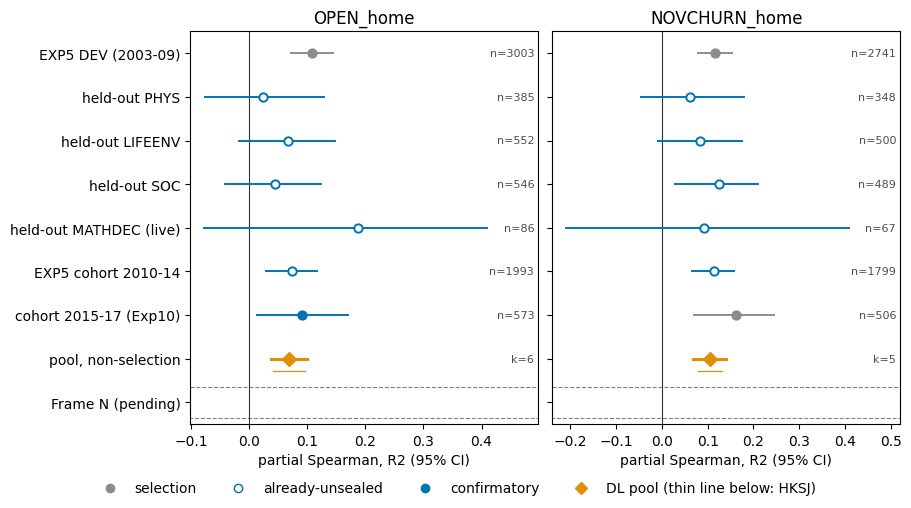

In [14]:
PALETTE = ["#0173B2", "#DE8F05", "#029E73"]
ORDER = [("B1_DEV", "EXP5 DEV (2003-09)"), ("B2_PHYS", "held-out PHYS"), ("B2_LIFEENV", "held-out LIFEENV"),
         ("B2_SOC", "held-out SOC"), ("B2_MATHDEC", "held-out MATHDEC (live)"),
         ("B3_EXP5_COHORT_2010_14", "EXP5 cohort 2010-14"), ("B4_COHORT_2015_17", "cohort 2015-17 (Exp10)")]

s = syn_out                          # original: json.loads((RES / "evidence_synthesis.json").read_text())
rows = {(r["body"], r["feature"]): r for r in s["rows"]}
fig, axes = plt.subplots(1, 2, figsize=(9, 5), sharey=False, layout="constrained")
for ax, f in zip(axes, ("OPEN_home", "NOVCHURN_home")):
    labels = []
    y = 0
    for b, lab in ORDER:
        r = rows[(b, f)]
        p = r["R2"]
        st = r["status"]
        col = "0.55" if st.startswith("selection") else PALETTE[0]
        face = col if st in ("confirmatory",) or st.startswith("selection") else "white"
        ax.plot(p["ci"], [y, y], color=col, lw=1.4, zorder=2)
        ax.plot([p["psp"]], [y], marker="o", ms=6, mec=col, mfc=face, mew=1.4, ls="none", zorder=3)
        labels.append(lab)
        ax.annotate(f"n={p['n']}", (1.0, y), xycoords=("axes fraction", "data"), xytext=(-3, 0),
                    textcoords="offset points", ha="right", va="center", fontsize=8, color="0.3")
        y += 1
    pool = s["pools"][f"{f}|R2"]["nonselection"]
    ax.plot(pool["hksj_ci"], [y + 0.28, y + 0.28], color=PALETTE[1], lw=0.9, zorder=2)
    ax.plot(pool["dl_ci"], [y, y], color=PALETTE[1], lw=2.2, zorder=2)
    ax.plot([pool["est"]], [y], marker="D", ms=7, color=PALETTE[1], ls="none", zorder=3)
    labels.append("pool, non-selection")
    ax.annotate(f"k={pool['k']}", (1.0, y), xycoords=("axes fraction", "data"), xytext=(-3, 0),
                textcoords="offset points", ha="right", va="center", fontsize=8, color="0.3")
    y += 1
    ax.axhspan(y - 0.35, y + 0.35, fill=False, ls="--", lw=0.8, ec="0.5")
    labels.append("Frame N (pending)")
    ax.axvline(0, color="0.2", lw=0.8, zorder=1)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels if f == "OPEN_home" else [])
    lo, hi = ax.get_xlim()
    ax.set_xlim(lo, hi + 0.12 * (hi - lo))
    ax.set_ylim(len(labels) - 0.5, -0.5)
    ax.set_xlabel("partial Spearman, R2 (95% CI)")
    ax.set_title(f)
handles = [Line2D([], [], marker="o", color="0.55", mfc="0.55", ls="none", label="selection"),
           Line2D([], [], marker="o", color=PALETTE[0], mfc="white", ls="none", label="already-unsealed"),
           Line2D([], [], marker="o", color=PALETTE[0], mfc=PALETTE[0], ls="none", label="confirmatory"),
           Line2D([], [], marker="D", color=PALETTE[1], ls="none", label="DL pool (thin line below: HKSJ)")]
fig.legend(handles=handles, loc="outside lower center", ncol=4, frameon=False)
plt.show()

**Reading.** `OPEN_home` has the same (positive) sign in all 6 non-selection bodies. The non-selection pool is
about +0.07 at R2, with I2 = 0. The DEV selection body is about 1.6 times larger, and this ratio is the shrinkage
expected from index selection. The pool is **descriptive**, not a confirmation: all non-selection bodies except the
2015-17 cohort had already been unsealed. The empty Frame-N row is the slot for this iteration's confirmatory
artifact. Held-out MATHDEC is the smallest body (n = 86), and its CI is the widest of all rows.